# Задание 4

## Многомерная регрессия

### *Цель работы:* изучение принципов решения задачи многомерной регрессии с использованием методов машинного обучения.
**Основные задачи:**

• изучение инструментария Python для реализации алгоритмов многомерной регрессии;

• освоение метода линейной регрессии;

• изучение методов оценки корректности модели многомерной линейной регрессии;

Проанализируем датасет **concrete.csv**.  Набор данных предоставляет информацию о прочности бетона на сжатие, который является наиболее важным материалом в гражданском строительстве, в зависимости от его компонентов и возраста.

**Атрибуты:**

• *Cement (component 1)* – kg in a m3 mixture

• *Blast Furnace Slag (component 2)* – kg in a m3 mixture

• *Fly Ash (component 3)* – kg in a m3 mixture

• *Water (component 4)* – kg in a m3 mixture

• *Superplasticizer (component 5)* – kg in a m3 mixture

• *Coarse Aggregate (component 6)* – kg in a m3 mixture


• *Fine Aggregate (component 7)* – kg in a m3 mixture

• *Age* – Day (1~365)

• *Concrete compressive strength* – MPa (целевая переменная)

# 1. Импортируйте необходимые библиотеки

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# 2. Импортируйте набор данных из файла blood.сsv и поместите его в объект DataFrame

In [4]:
df = pd.read_csv("concrete.csv")

# 3. Выведите данные

In [5]:
df.head(12)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29
5,255.0,0.0,0.0,192.0,0.0,889.8,945.0,90,21.86
6,166.8,250.2,0.0,203.5,0.0,975.6,692.6,7,15.75
7,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,56,36.64
8,296.0,0.0,0.0,192.0,0.0,1085.0,765.0,28,21.65
9,155.0,184.0,143.0,194.0,9.0,880.0,699.0,28,28.99


# 4. Получим информацию о датасете

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


# 5. Проверим наличие пропущенных значений и выбросов

Проверим датасе на пропущенные значения:

In [7]:
print(df.isnull().sum())

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64


Нулевые значения в датасете отсутствуют. 

Далее проверим датасет на выбросы:

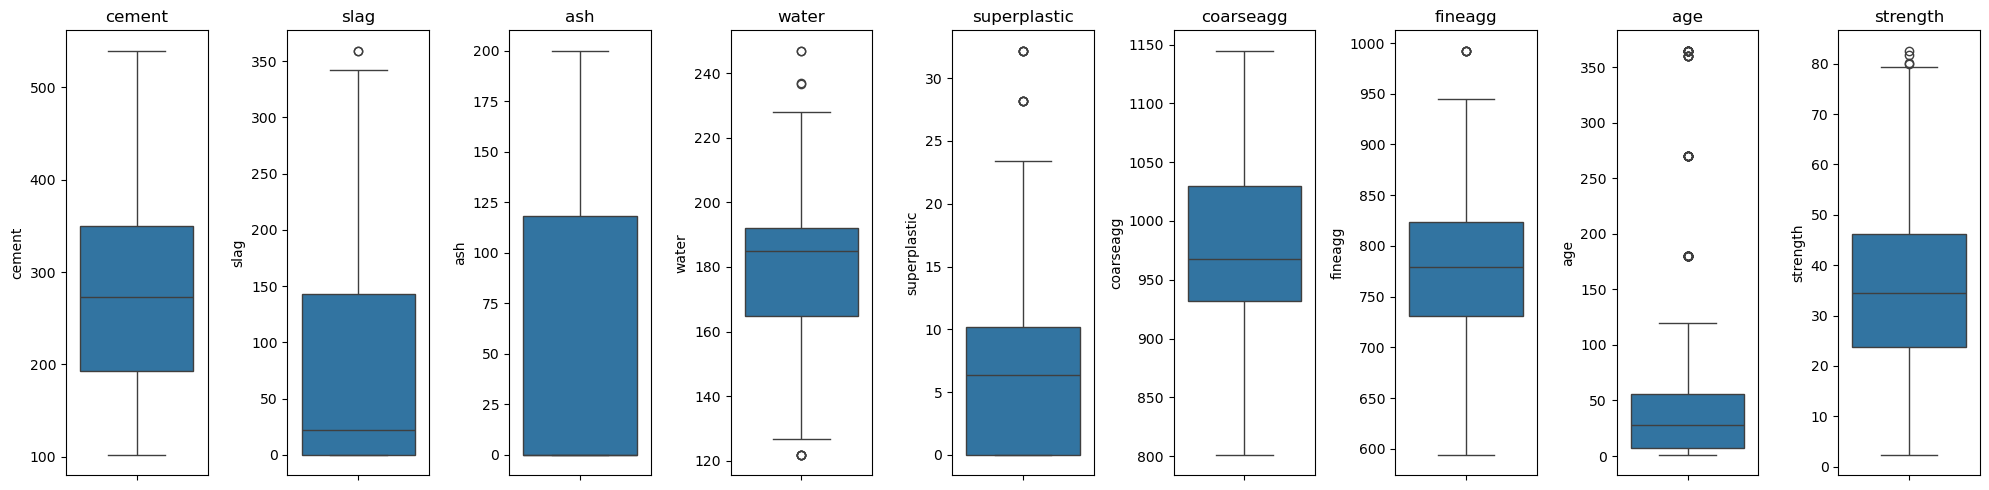

In [8]:
fig, axes = plt.subplots(1, 9, figsize=(20, 5))

numeric_cols = [
    'cement',
    'slag',
    'ash',
    'water',
    'superplastic',
    'coarseagg',
    'fineagg',
    'age',
    'strength'
]

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# 6. Разделяем данные на признаки и целевую переменную

In [12]:
y = df['strength']
X = df.drop('strength', axis=1)

X.head(12)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28
5,255.0,0.0,0.0,192.0,0.0,889.8,945.0,90
6,166.8,250.2,0.0,203.5,0.0,975.6,692.6,7
7,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,56
8,296.0,0.0,0.0,192.0,0.0,1085.0,765.0,28
9,155.0,184.0,143.0,194.0,9.0,880.0,699.0,28


In [15]:
y = df['strength']
X = df.drop('strength', axis=1)
X

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28
...,...,...,...,...,...,...,...,...
1025,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28
1026,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3
1027,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1028,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270


# 7. Разделяем данные на тренировочный и тестовый наборы

75% данных для обучения и 25% - для тестирования

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0)

# 8. Применяем операцию нормализации для численной устойчивости

In [1]:
X_train_scaled = scaler.fit_transform(X_train)

scaler.mean_, scaler.scale_

NameError: name 'scaler' is not defined

# 9. Масштабируем признаки обучающей выборки

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler

(array([280.91658031,  74.80492228,  53.28743523, 181.60997409,
          6.15854922, 972.85777202, 774.48562176,  46.62564767]),
 array([104.56944979,  87.21611596,  63.39600914,  21.5529404 ,
          6.12764414,  77.12956786,  80.97134264,  63.71386828]))

# 10. Обучаем модель линейной регрессии

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train_scaled, y_train)
model

LinearRegression()

# 11. Делаем прогноз на основе данных тестирования

In [37]:
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)

y_pred[:5]

array([25.33374599, 25.16226003, 17.29028657, 40.29891082, 56.95443286])

In [38]:
from sklearn.metrics import root_mean_squared_error

print('Root Mean Squared Error (RMSE):', root_mean_squared_error(y_test, y_pred))

Root Mean Squared Error (RMSE): 10.625290975269616


In [39]:
from sklearn.metrics import r2_score
print('R2:', np.round(r2_score(y_test, y_pred), 2))

R2: 0.6


In [40]:
# оценим R-квадрат
model.score(X_test_scaled, y_test)

0.5982240239819626

# 12. Итоговое уравнение

In [41]:
print('Coefficents: ', model.coef_)

Coefficents:  [11.71362629  7.98542385  5.19153582 -3.67162313  1.99330241  1.03852849
  1.04245303  7.35697805]


In [42]:
print('Intercept: ', model.intercept_)

Intercept:  35.994300518134715


# 13. Визуализация результатов регрессии

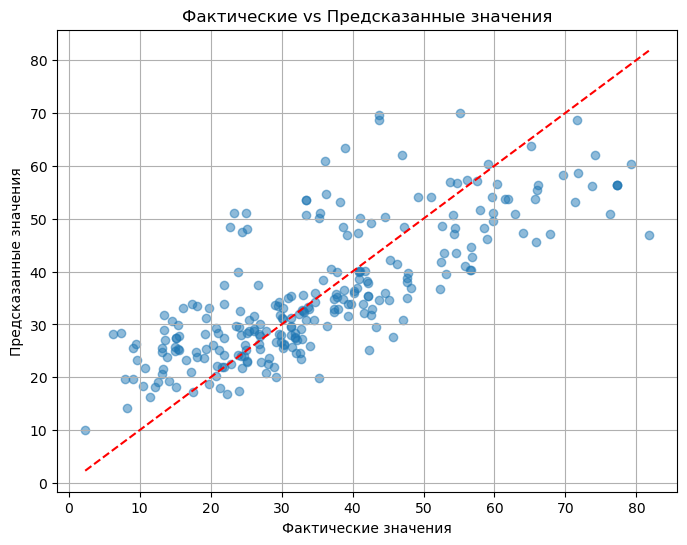

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические vs Предсказанные значения")
plt.grid()
plt.show()

# 14. Остатки регрессии 

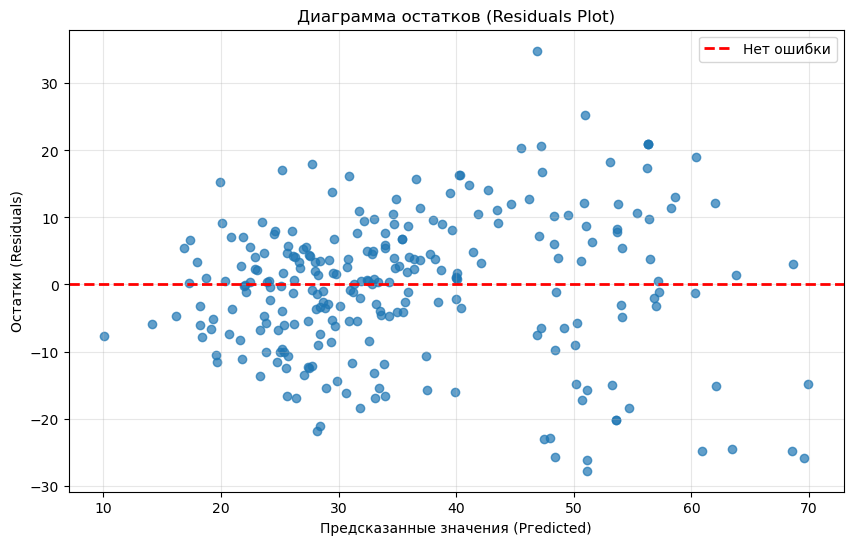

In [45]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter (y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Heт oшибки')
plt.xlabel('Предсказанные значения (Ргedicted)')
plt.ylabel('Oстатки (Residuals)')
plt.title('Диаграмма остатков (Residuals Plot)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Остатки беспорядочно разбросаны вокруг горизонтальной красной линии (нуля), нет никаких явных дуг, форм или конусов. 